# Ultimate Data Science Challenge

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part I: EDA

In [2]:
with open('logins.json', 'r', encoding='utf-8') as f:
    data_logins = json.load(f)

In [3]:
df = pd.DataFrame(data_logins)

df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   login_time  93142 non-null  str  
dtypes: str(1)
memory usage: 727.8 KB


### Convert timestamps to datetime values

In [5]:
# Convert login times from strings to datetime
df['login_time'] = pd.to_datetime(df['login_time'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 727.8 KB


### Dataset coverage

In [6]:
start_date = df['login_time'].min()
end_date = df['login_time'].max()

print('Start:', start_date)
print('End:', end_date)
print('Duration:', end_date - start_date)

Start: 1970-01-01 20:12:16
End: 1970-04-13 18:57:38
Duration: 101 days 22:45:22


The dataset contains 93,142 login records covering approximately January 1 through April 13, 1970. Because the first and final days are incomplete, daily totals on those dates should be interpreted cautiously.

### Agg logins into 15-minute intervals

Each row is one login. I set the timestamp as the index, then counted how many logins happened in each 15-minute interval.

In [7]:
# Use the timestamp as the DataFrame index
df = df.set_index('login_time')

In [8]:
# Count the number of logins in each 15-minute interval
login_counts = df.resample('15min').size()

login_counts.head()

login_time
1970-01-01 20:00:00    2
1970-01-01 20:15:00    6
1970-01-01 20:30:00    9
1970-01-01 20:45:00    7
1970-01-01 21:00:00    1
Freq: 15min, dtype: int64

In [9]:
login_counts.describe()

count    9788.000000
mean        9.515938
std         8.328818
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        73.000000
dtype: float64

A typical 15-minute period had around 7 logins, while the average was about 9.5. Counts ranged from 0 to 73. Demand is varied with some high spikes worth looking further into. 

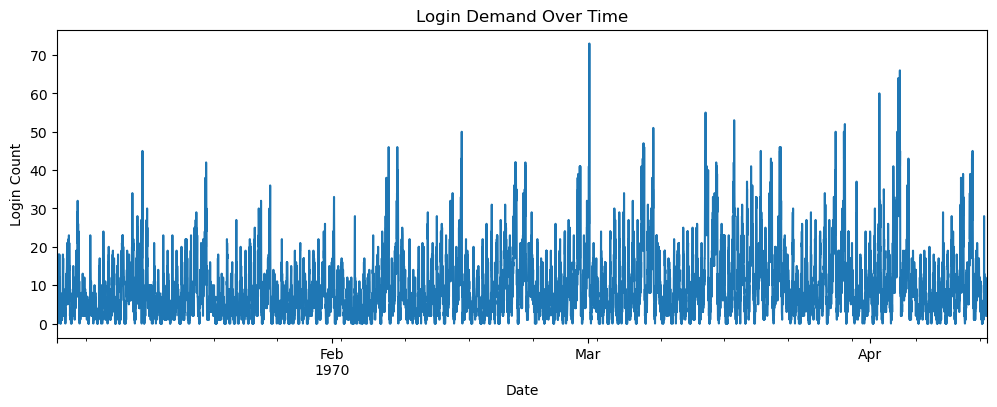

In [10]:
login_counts.plot(figsize=(12, 4))

plt.title('Login Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Login Count')
plt.show()

### Demand Patterns

The full time series shows repeated spikes, but it is too dense to see exactly when the spikes happen or what the cycle is. I want to look at weekly and daily patterns to see more clearly. 

In [11]:
login_df = login_counts.to_frame(name='login_count')

# Monday = 0, Sunday = 6
login_df['day_num'] = login_df.index.dayofweek
login_df['day_of_week'] = login_df.index.day_name()

In [12]:
weekday_pattern = (
    login_df
    .groupby(['day_num', 'day_of_week'])['login_count']
    .mean()
    .reset_index())

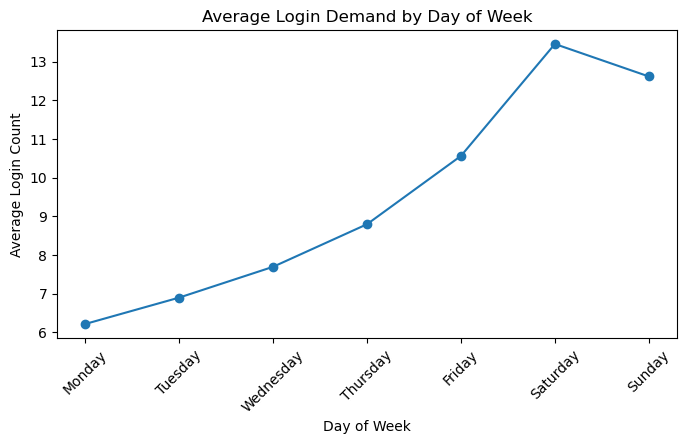

In [13]:
plt.figure(figsize=(8, 4))

plt.plot(
    weekday_pattern['day_of_week'],
    weekday_pattern['login_count'],
    marker='o')

plt.title('Average Login Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Login Count')
plt.xticks(rotation=45)
plt.show()

Login demand increases gradually through the work week, peaks on Saturday, and then drops again on Sunday. Demand is strongest heading into the weekend, peaking on Saturday.

In [14]:
login_df['hour'] = login_df.index.hour

In [15]:
daily_pattern = (
    login_df
    .groupby('hour')['login_count']
    .mean()
    .reset_index())

In [16]:
hour_labels = [
    '12 AM', '1 AM', '2 AM', '3 AM', '4 AM', '5 AM',
    '6 AM', '7 AM', '8 AM', '9 AM', '10 AM', '11 AM',
    '12 PM', '1 PM', '2 PM', '3 PM', '4 PM', '5 PM',
    '6 PM', '7 PM', '8 PM', '9 PM', '10 PM', '11 PM']

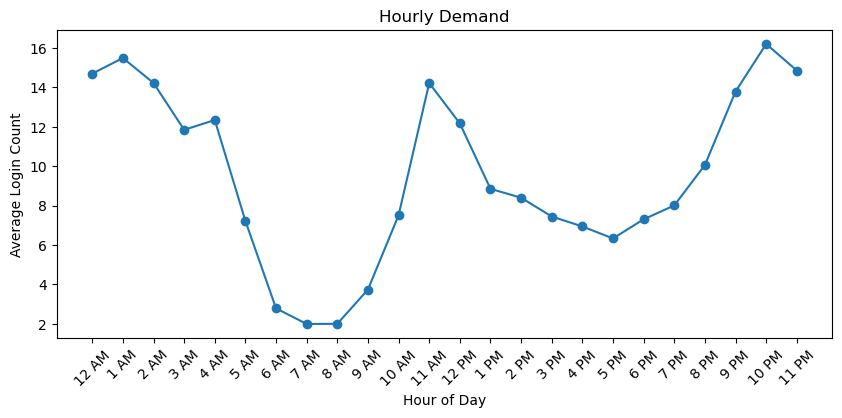

In [17]:
plt.figure(figsize=(10, 4))

plt.plot(
    daily_pattern['hour'],
    daily_pattern['login_count'],
    marker='o')

plt.title('Hourly Demand')
plt.xlabel('Hour of Day')
plt.ylabel('Average Login Count')
plt.xticks(range(24), hour_labels, rotation=45)
plt.show()

### Login Demand by Day and Hour

To examine how the daily cycle changes throughout the week, I calculated the average login count for every weekday and hour combination.

In [18]:
day_hour_pattern = (
    login_df
    .groupby(['day_num', 'day_of_week', 'hour'])['login_count']
    .mean().reset_index())

day_hour_heatmap = day_hour_pattern.pivot(
    index=['day_num', 'day_of_week'],
    columns='hour', values='login_count')

day_hour_heatmap.index = day_hour_heatmap.index.get_level_values('day_of_week')

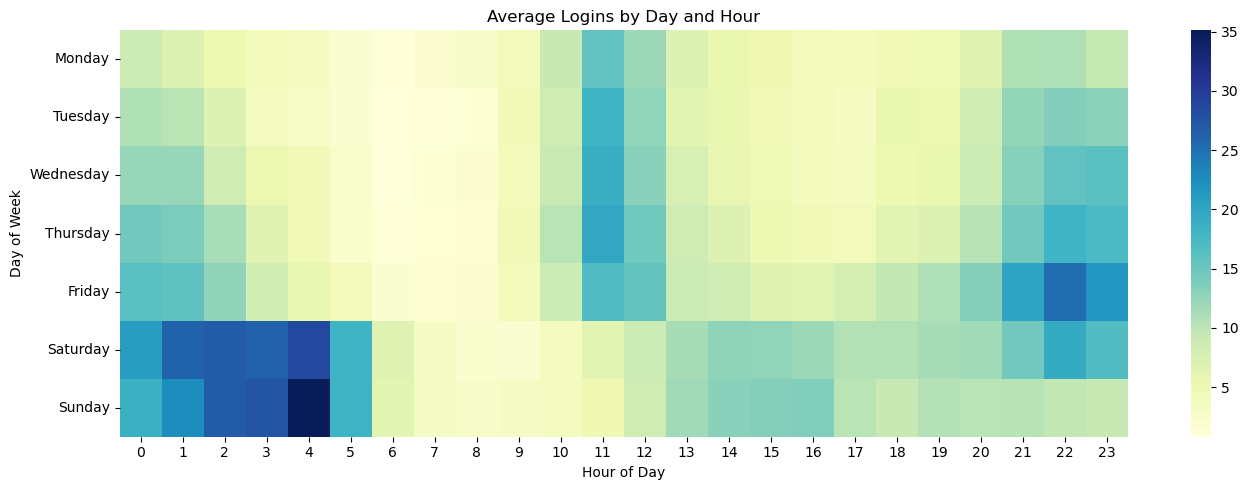

In [19]:
plt.figure(figsize=(14, 5))

sns.heatmap(
    day_hour_heatmap,
    cmap='YlGnBu')

plt.title('Average Logins by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

In [20]:
peak_hours = daily_pattern.nlargest(5, 'login_count')
low_hours = daily_pattern.nsmallest(5, 'login_count')

print('Highest-demand hours:')
display(peak_hours)

print('Lowest-demand hours:')
display(low_hours)

Highest-demand hours:


,hour,login_count
22,22,16.193627
1,1,15.482843
23,23,14.848039
0,0,14.688725
2,2,14.215686


Lowest-demand hours:


,hour,login_count
7,7,1.997549
8,8,2.004902
6,6,2.789216
9,9,3.742647
17,17,6.333333


In [21]:
# using nlargest and nsmallest to see the specific login counts from the heatmap
peak_day_hours = day_hour_pattern.nlargest(5, 'login_count')
low_day_hours = day_hour_pattern.nsmallest(5, 'login_count')

print('Highest-demand day and hour combinations:')
display(
    peak_day_hours[
        ['day_of_week', 'hour', 'login_count']])

print('Lowest-demand day and hour combinations:')
display(
    low_day_hours[
        ['day_of_week', 'hour', 'login_count']])

Highest-demand day and hour combinations:


,day_of_week,hour,login_count
148,Sunday,4,35.116667
124,Saturday,4,28.650000
147,Sunday,3,27.450000
122,Saturday,2,26.800000
146,Sunday,2,26.800000


Lowest-demand day and hour combinations:


,day_of_week,hour,login_count
30,Tuesday,6,0.821429
54,Wednesday,6,0.857143
6,Monday,6,1.100000
31,Tuesday,7,1.142857
78,Thursday,6,1.196429


- Logins follow a daily and weekly pattern
- demand peaks at 10pm and stays high between 12am-2am
- there's low demand between 6am-9am, the lowest point at 7am
- demand is especially high during the weekends, overnight
- the highest point being Sundays at 4am with around 35 logins in a 15-minute interval
- the slowest points are Tuesdays at 6am with 0.8 logins

### Data quality checks

In [22]:
missing_timestamps = df.index.isna().sum()
repeated_timestamps = df.index.duplicated().sum()

zero_intervals = (login_counts == 0).sum()
zero_interval_pct = zero_intervals / len(login_counts) * 100

is_zero = login_counts.eq(0)
zero_groups = is_zero.ne(is_zero.shift()).cumsum()
longest_zero_run = is_zero.groupby(zero_groups).sum().max()

print('Missing timestamps:', missing_timestamps)
print('Repeated timestamps:', repeated_timestamps)
print('Zero-login intervals:', zero_intervals)
print('Percent of intervals with zero logins:', round(zero_interval_pct, 1), '%')
print('Longest zero-login period:', longest_zero_run * 15, 'minutes')

Missing timestamps: 0
Repeated timestamps: 877
Zero-login intervals: 407
Percent of intervals with zero logins: 4.2 %
Longest zero-login period: 75 minutes


- no missing timestamps
- 877 repeated timestamps, but multiple users could have logged in at that time
- 407 15-min intervals (4%) of all 15-minute intervals, had no logins
- the longest period with no logins was 75 minutes which could be worth invesstigating
- the first and last days are not full 24 hours, so we can't calulate their daily totalys accurately

### Part I Summary

The dataset covers about 100 full days (plus 2 partial days) between Jan - April 1970. Demand follows a clear daily and weekly cycle, increasing toward the weekend and shifting heavily into late-night hours. There are no obvious major data-quality issues, but the 75-minute period with no logins could be investigated.

- Median: 7 logins per 15 min interval
- Saturday has the highest overall demand
- demand peaks at 10pm and stays high between 12am-2am.
- weekend overnight demand is especially high, peaking Sunday at 4am (35 logins/15-minute interval)
- demand is lowest between 6am-9am, with Tuesday at 6am at the lowest

## Part II: Experiment and Metrics Design

### Key measure of success

<b>The key metric:</b> average percentage of each driver's active time during which they were available to receive ride requests from both cities.

`driver availability rate = time available in both cities ÷ total active time`

then compare rates between control and test groups.

I would record the following data if possible:

- driver's active hours with timestamps and which cities they're available in
- driver location when a ride request is received
- pickup and drop-off locations
- whether the driver accepted and completed the pickup

A driver who's available in both cities for five minutes shouldn't count the same as someone available in both cities for an entire shift, so the timestamps are important. It would also allow me to compare availability during weekdays, weekends, and different times of day.

I'd also look into the percentage of cross-city ride requests that are accepted and picked up to see if that rate increases on the test group.

Initally my instinct was to measure toll crossings, but it doesn't address a drivers' availability. There are also different scenarios that would add to toll crossing counts, which wouldn't really give me the information I need or support to implement a change. 

1. The driver crosses with a passenger who is being dropped off in the other city.
2. The driver crosses without a passenger to make a pickup (or just crosses to be available in the other city).
3. The driver drops someone off in the other city, stays available, and completes another pickup there.

The last scenario is operationally valuable because the driver serves both cities without having an 'empty toll cross'

### Experiment setup

I'd randomly split eligible drivers into a control group and a treatment group, where the control group continues paying its own tolls, and the treatment group is notified that Ultimate will reimburse its tolls.

Before splitting the drivers, I might group them based on:

* home city
* normal trip volume
* previous cross-city activity
* typical weekday and weekend activity

To make sure both groups start with similar behavior.

I'd use 1 month of existing data as a baseline, then run the experiment for a month so it includes multiple weekdays and weekends. During the experiment, I'd track each driver's active time, city availability, location, ride requests, accepted requests, pickups, drop-offs, bridge crossings, and reimbursement costs (to measure if people are actually using it).

The main comparison metric is the average percentage of each driver's active time spent available in both cities. I would compare the treatment and control groups during the experiment, and see the change from the baseline data as well.

One issue is that not every treatment driver will respond to the offer. Some might ignore the notification, never enable both cities, or never use a reimbursed toll.

### Statistical Tests

1. <b>ANCOVA:</b> compare the control/test groups during the experiment while accounting for each driver's baseline activity. It's important because some drivers may have already been more active in both cities before the reimbursement was offered.
2. <b>Welch’s t-test:</b> a more basic comparison between averages of control/test groups to see 2 city activity, but doesn't account for baseline activity.
3. <b>Z-test:</b> compare the percentage of drivers in test/control who turn on 2 city availability at least once. It doesn't account for how long they stayed available (the goal is to have more driver coverage between both cities).

### Interpreting the results and recommendations

I'd consider the experiment successful if the test group had a statistically significant increase in two-city availability after accounting for baseline activity. I'd look for a p-value < 0.05, but also consider the size of the increase, the confidence interval, and whether the operational benefits justified the reimbursement costs.

I might recommend expanding if:

* increases two-city availability / overall coverage
* more completed rides or less unfulfilled ride requests/cancellations
* shorter wait times
* does not create excessive empty bridge crossings
* produces enough value to justify the toll reimbursements

If 2 city availability increases but overall rides don't increase, then it doesn't justify a full roll out.

# Part III Predictive Model

`trips_in_first_30_days` is a predictor, so include users with zero trips; they may be informative. You cannot study whether someone booked near the end of their first 30 days because trip dates are not provided. Clean missing ratings and phone values, convert dates, create the retention target, one-hot encode categories, and exclude last_trip_date from predictors to prevent leakage. Compare logistic regression with Random Forest; evaluate ROC-AUC, precision, recall, and confusion matrix.

In [23]:
with open('ultimate_data_challenge.json', 'r', encoding='utf-8') as f:
    user_data = json.load(f)

users_df = pd.DataFrame(user_data)

In [24]:
print('Rows and columns:', users_df.shape)

display(users_df.head())

users_df.info()

Rows and columns: (50000, 12)


,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  str    
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  str    
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  str    
 6   phone                   49604 non-null  str    
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), str(4)
memory usage: 4.2 MB


In [25]:
users_df.isna().sum().sort_values(ascending=False)

avg_rating_of_driver      8122
phone                      396
avg_rating_by_driver       201
city                         0
signup_date                  0
trips_in_first_30_days       0
last_trip_date               0
avg_surge                    0
surge_pct                    0
ultimate_black_user          0
weekday_pct                  0
avg_dist                     0
dtype: int64

A user is considered `retained` if they completed a trip within the final 30 days covered by the dataset.

In [27]:
# convert the date columns to datetime since it started as a string
users_df['signup_date'] = pd.to_datetime(users_df['signup_date'])
users_df['last_trip_date'] = pd.to_datetime(users_df['last_trip_date'])

In [29]:
# find out what date the data was pulled, then cutoff observations 30 days before that
observation_date = users_df['last_trip_date'].max()
retention_cutoff = observation_date - pd.Timedelta(days=30)

print('Observation date:', observation_date)
print('Retention cutoff:', retention_cutoff)

Observation date: 2014-07-01 00:00:00
Retention cutoff: 2014-06-01 00:00:00


In [30]:
# creating a new column to determine if a user was retained or not, saving as an int. This is the target variable.
users_df['retained'] = (
    users_df['last_trip_date'] >= retention_cutoff).astype(int)

In [31]:
# counting the number of all retained users. Since it's counting up 1s and 0s, it will get the mean of the value counts and return the rate.
retention_counts = users_df['retained'].value_counts()
retention_rate = users_df['retained'].mean()

print(retention_counts)
print('Retention rate:', round(retention_rate * 100, 1), '%')

retained
0    31196
1    18804
Name: count, dtype: int64
Retention rate: 37.6 %


- 18,804 out of 50,000 users were retained (37.6%)
- most users were not retained, so I can't rely solely on accuracy when evaluating the model

### Clean missing values

In [32]:
# keep track of observations that were originally missing values. 
# the model will still be able to tell if something was originally missing or imputed
users_df['rating_of_driver_missing'] = (
    users_df['avg_rating_of_driver'].isna().astype(int))

users_df['rating_by_driver_missing'] = (
    users_df['avg_rating_by_driver'].isna().astype(int))

# using the column median to impute
users_df['avg_rating_of_driver'] = (users_df['avg_rating_of_driver']
    .fillna(users_df['avg_rating_of_driver'].median()))

users_df['avg_rating_by_driver'] = (users_df['avg_rating_by_driver']
    .fillna(users_df['avg_rating_by_driver'].median()))

users_df['phone'] = users_df['phone'].fillna('unknown')

In [33]:
users_df.isna().sum().sort_values(ascending=False).head()

city                      0
trips_in_first_30_days    0
signup_date               0
avg_rating_of_driver      0
avg_surge                 0
dtype: int64

In [35]:
# creating a new column to understand an accounts age/time on the platform
users_df['account_age_days'] = (observation_date - users_df['signup_date']).dt.days

### Comparing retained and non-retained users

In [37]:
# creating a df to quickly compare the numbers between the 2 groups
numeric_features = [
    'trips_in_first_30_days','avg_dist',
    'avg_rating_by_driver','avg_rating_of_driver','avg_surge',
    'surge_pct','weekday_pct','account_age_days']

retention_comparison = (users_df.groupby('retained')[numeric_features].mean().T)

retention_comparison.columns = ['not_retained', 'retained']
retention_comparison['difference'] = (retention_comparison['retained']- retention_comparison['not_retained'])

retention_comparison

,not_retained,retained,difference
trips_in_first_30_days,1.658482,3.306318,1.647836
avg_dist,6.207939,5.114788,-1.093150
avg_rating_by_driver,4.788588,4.763226,-0.025362
avg_rating_of_driver,4.668397,4.619581,-0.048816
avg_surge,1.075339,1.073809,-0.001530
surge_pct,8.666739,9.152797,0.486058
weekday_pct,60.647032,61.389034,0.742003
account_age_days,165.317957,165.683206,0.365248


This tells me that aside from 'trips in first 30 days', both groups had very similar experiences in terms of trip distance, driver quality, pricing, and other quantitative features. I'm curious to investing other features now since this wasn't very telling.

In [40]:
# using a for loop to create a dataframe that helps me understand how many users are in each city, 
# what type of phone they have, and if they're black users.
for column in ['city', 'phone', 'ultimate_black_user']:
    summary = (users_df.groupby(column)['retained'].agg(
            total_users='size',
            retained_users='sum',
            retention_rate='mean'))

    summary['retention_rate'] = (summary['retention_rate'] * 100).round(1)

    display(summary.sort_values('retention_rate', ascending=False))

,total_users,retained_users,retention_rate
city,,,
King's Landing,10130,6363,62.8
Winterfell,23336,8213,35.2
Astapor,16534,4228,25.6


,total_users,retained_users,retention_rate
phone,,,
iPhone,34582,15525,44.9
unknown,396,133,33.6
Android,15022,3146,20.9


,total_users,retained_users,retention_rate
ultimate_black_user,,,
True,18854,9497,50.4
False,31146,9307,29.9


Key takeaways and follow ups: 

- King's Landing has a substantially higher retention rate: what could be the reason for this?
- iPhone users have much higher retention rates as well: why is that?
- Black users have a higher retention rate, but that doesn't tell me much

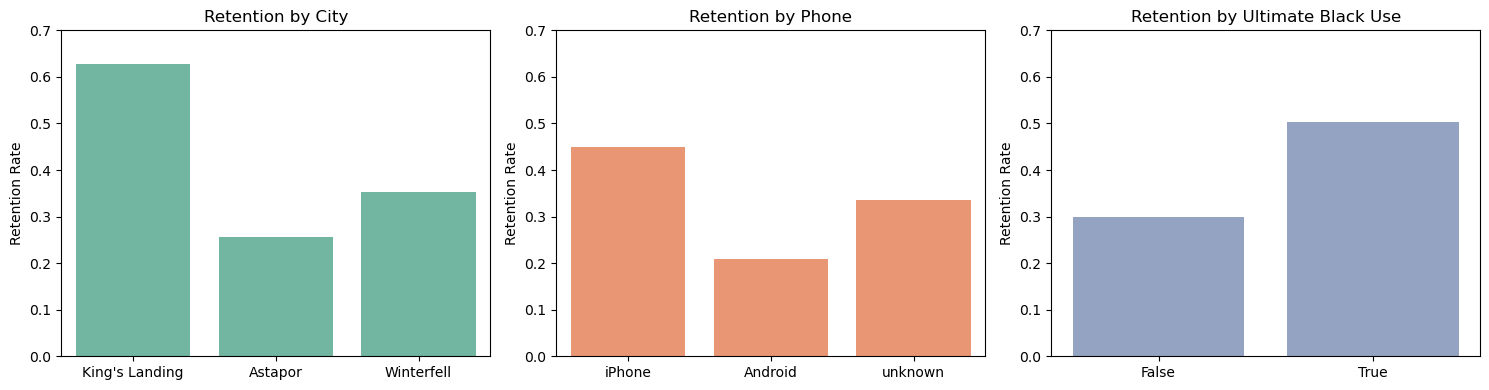

In [42]:
# using subplots to easily/visually compare categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(
    data=users_df, x='city', y='retained',
    errorbar=None, ax=axes[0], color='#66c2a5')
axes[0].set_title('Retention by City')

sns.barplot(
    data=users_df, x='phone', y='retained',
    errorbar=None, ax=axes[1], color='#fc8d62')
axes[1].set_title('Retention by Phone')

sns.barplot(
    data=users_df, x='ultimate_black_user', y='retained',
    errorbar=None, ax=axes[2], color='#8da0cb')
axes[2].set_title('Retention by Ultimate Black Use')

for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('Retention Rate')
    ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.show()

In [43]:
# creating bins to easily see what related to higher retention before actually modeling
users_df['trip_group_eda'] = pd.cut(
    users_df['trips_in_first_30_days'],
    bins=[-1, 0, 1, 3, 7, float('inf')],
    labels=['0', '1', '2-3', '4-7', '8+'])

users_df['distance_group_eda'] = pd.qcut(
    users_df['avg_dist'],
    q=5,
    labels=['lowest', 'low', 'middle', 'high', 'highest'])

trip_retention = (
    users_df.groupby('trip_group_eda', observed=True)['retained']
    .mean()
    .reset_index())

distance_retention = (
    users_df.groupby('distance_group_eda', observed=True)['retained']
    .mean()
    .reset_index())

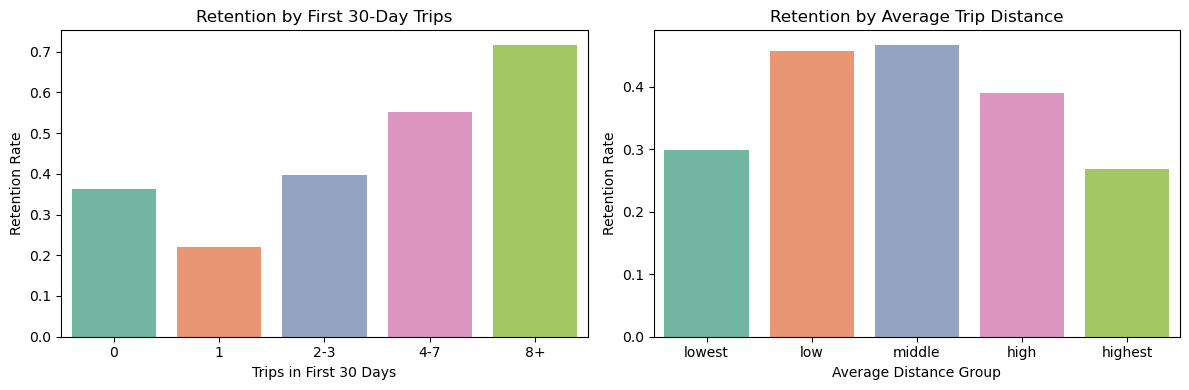

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=trip_retention,
    x='trip_group_eda',
    y='retained',
    hue='trip_group_eda',
    palette='Set2',
    dodge=False,
    width=0.8,
    legend=False,
    ax=axes[0])
axes[0].set_title('Retention by First 30-Day Trips')
axes[0].set_xlabel('Trips in First 30 Days')
axes[0].set_ylabel('Retention Rate')

sns.barplot(
    data=distance_retention,
    x='distance_group_eda',
    y='retained',
    hue='distance_group_eda',
    palette='Set2',
    dodge=False,
    width=0.8,
    legend=False,
    ax=axes[1])
axes[1].set_title('Retention by Average Trip Distance')
axes[1].set_xlabel('Average Distance Group')
axes[1].set_ylabel('Retention Rate')

plt.tight_layout()
plt.show()